In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from os.path import join
import os
from matplotlib import pyplot as plt

## Silhouette saving

In [ ]:
def filtering(binary_frame):
    roi_mask = np.vstack((np.zeros((95, 480), dtype=np.uint8), np.ones((360 - 95, 480), dtype=np.uint8)))
    binary_frame = binary_frame * roi_mask
    kernel = np.ones((5, 5), np.uint8)
    binary_frame = cv2.morphologyEx(binary_frame, cv2.MORPH_CLOSE, kernel)
    binary_frame = cv2.morphologyEx(binary_frame, cv2.MORPH_OPEN, kernel)
    return binary_frame

def process_frame(frame, binary_frame, G):
    global iPedestrian
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_frame, connectivity=8)
    for i in range(num_labels):
        x, y, w, h, area = stats[i]
        if area > 100 and h > w * 1.3 and h > 30 and w > 30:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255,0,0), 2)
            ROI = G[y:y+h, x:x+w]
            cv2.imwrite('silhouettes_raw/sample_%06d.png' % iPedestrian,ROI)
            iPedestrian += 1

    return frame

In [ ]:
cap = cv2.VideoCapture('vid1_IR.wm')
iPedestrian = 0

while (cap.isOpened()):
    ret, frame = cap.read()
    G = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    _, G_binarized = cv2.threshold(G, 45, 255, cv2.THRESH_BINARY)
    G_filtered = filtering(G_binarized)
    G_processed = process_frame(frame, G_binarized, G)
    cv2.imshow('IR', G_processed)
    if cv2.waitKey(1) & 0xFF == ord('q'): 
        break
cap.release()
cv2.destroyAllWindows()

## Silhouette pattern

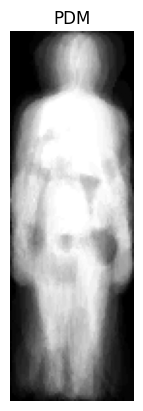

In [2]:
TARGET_SIZE = (64, 192)

pdm = np.zeros((192, 64), dtype=np.float32)

image_counter = 0

for filename in os.listdir("silhouettes"):
    path = os.path.join("silhouettes", filename)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, img = cv2.threshold(img, 45, 255, cv2.THRESH_BINARY)
    img = cv2.resize(img, TARGET_SIZE)

    _, binary = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY)

    pdm += binary.astype(np.float32)
    image_counter += 1

pdm /= image_counter

plt.imshow(pdm, cmap="gray")
plt.axis("off")
plt.title("PDM")
plt.show()

## Object detection